# `scVI` correction, leiden clustering and manual annotation of the epithelial cells

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 24th January 2025\
**Last modified date:** 29th January 2025

#### **Objective**

This notebook continues the process for annotation of epithelial cell states. We already annotated cells by label transfer and validated predicted cell states by labels transfer, the purpose of the next steps are:
1. Annotate subpopulations of the enteroendocrine cells
2. Re-annnotate subpopulations of other differentiated secretory cells
3. Identify Microfold cells among differentiated absorptive cells

## Import packages

In [1]:
import scvi
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup working environment

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [2]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [ ]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_scVI_scANVI_epithelial_cellstates_AM_27012025_133833_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 110105 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [8]:
duplicated_obs = adata.obs.index.duplicated().sum()
print(f"Number of duplicated observation indexes: {duplicated_obs}")

Number of duplicated observation indexes: 49581


In [9]:
adata.obs.index = adata.obs.index.astype(str)

In [10]:
adata.obs_names_make_unique()

In [11]:
duplicated_obs = adata.obs.index.duplicated().sum()
print(f"Number of duplicated observation indexes: {duplicated_obs}")

Number of duplicated observation indexes: 0


In [12]:
region_map = {
    'duodenum': 'small intestine',
    'ileum': 'small intestine',
    'small intestine': 'small intestine',
    'terminal ileum': 'small intestine',
    'jejunum': 'small intestine',
    'sigmoid colon': 'large intestine',
    'caecum': 'large intestine',
    'ascending colon': 'large intestine',
    'transverse colon': 'large intestine',
    'large intestine': 'large intestine',
    'descending colon': 'large intestine',
    'appendix': 'large intestine',
    'colon': 'large intestine',
    'rectum': 'large intestine'
}

adata.obs['gut_region'] = adata.obs['organism_part'].map(region_map)

## EEC

In [13]:
adata_EEC = adata[adata.obs['cellstates_scANVI'] == 'EEC']

### Extract highly variable genes

In [14]:
adata_EEC.layers['counts'] = adata_EEC.X.copy()

In [15]:
sc.pp.highly_variable_genes(
    adata_EEC,
    flavor = "seurat_v3",
    n_top_genes = 200,
    layer = "counts",
    batch_key = "library_preparation_protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Run scVI

In [16]:
scvi.model.SCVI.setup_anndata(adata_EEC, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Protocol REF'],
                              layer = 'counts')

In [17]:
scvi_model = scvi.model.SCVI(adata_EEC,
                            n_latent = 10, 
                            n_hidden = 64,
                            n_layers = 1, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [18]:
scvi_model.train(100, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.06it/s, v_num=1, train_loss_step=83.4, train_loss_epoch=99.6]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.20it/s, v_num=1, train_loss_step=83.4, train_loss_epoch=99.6]


In [19]:
adata_EEC.obsm["X_scVI"] = scvi_model.get_latent_representation(adata_EEC)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [20]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

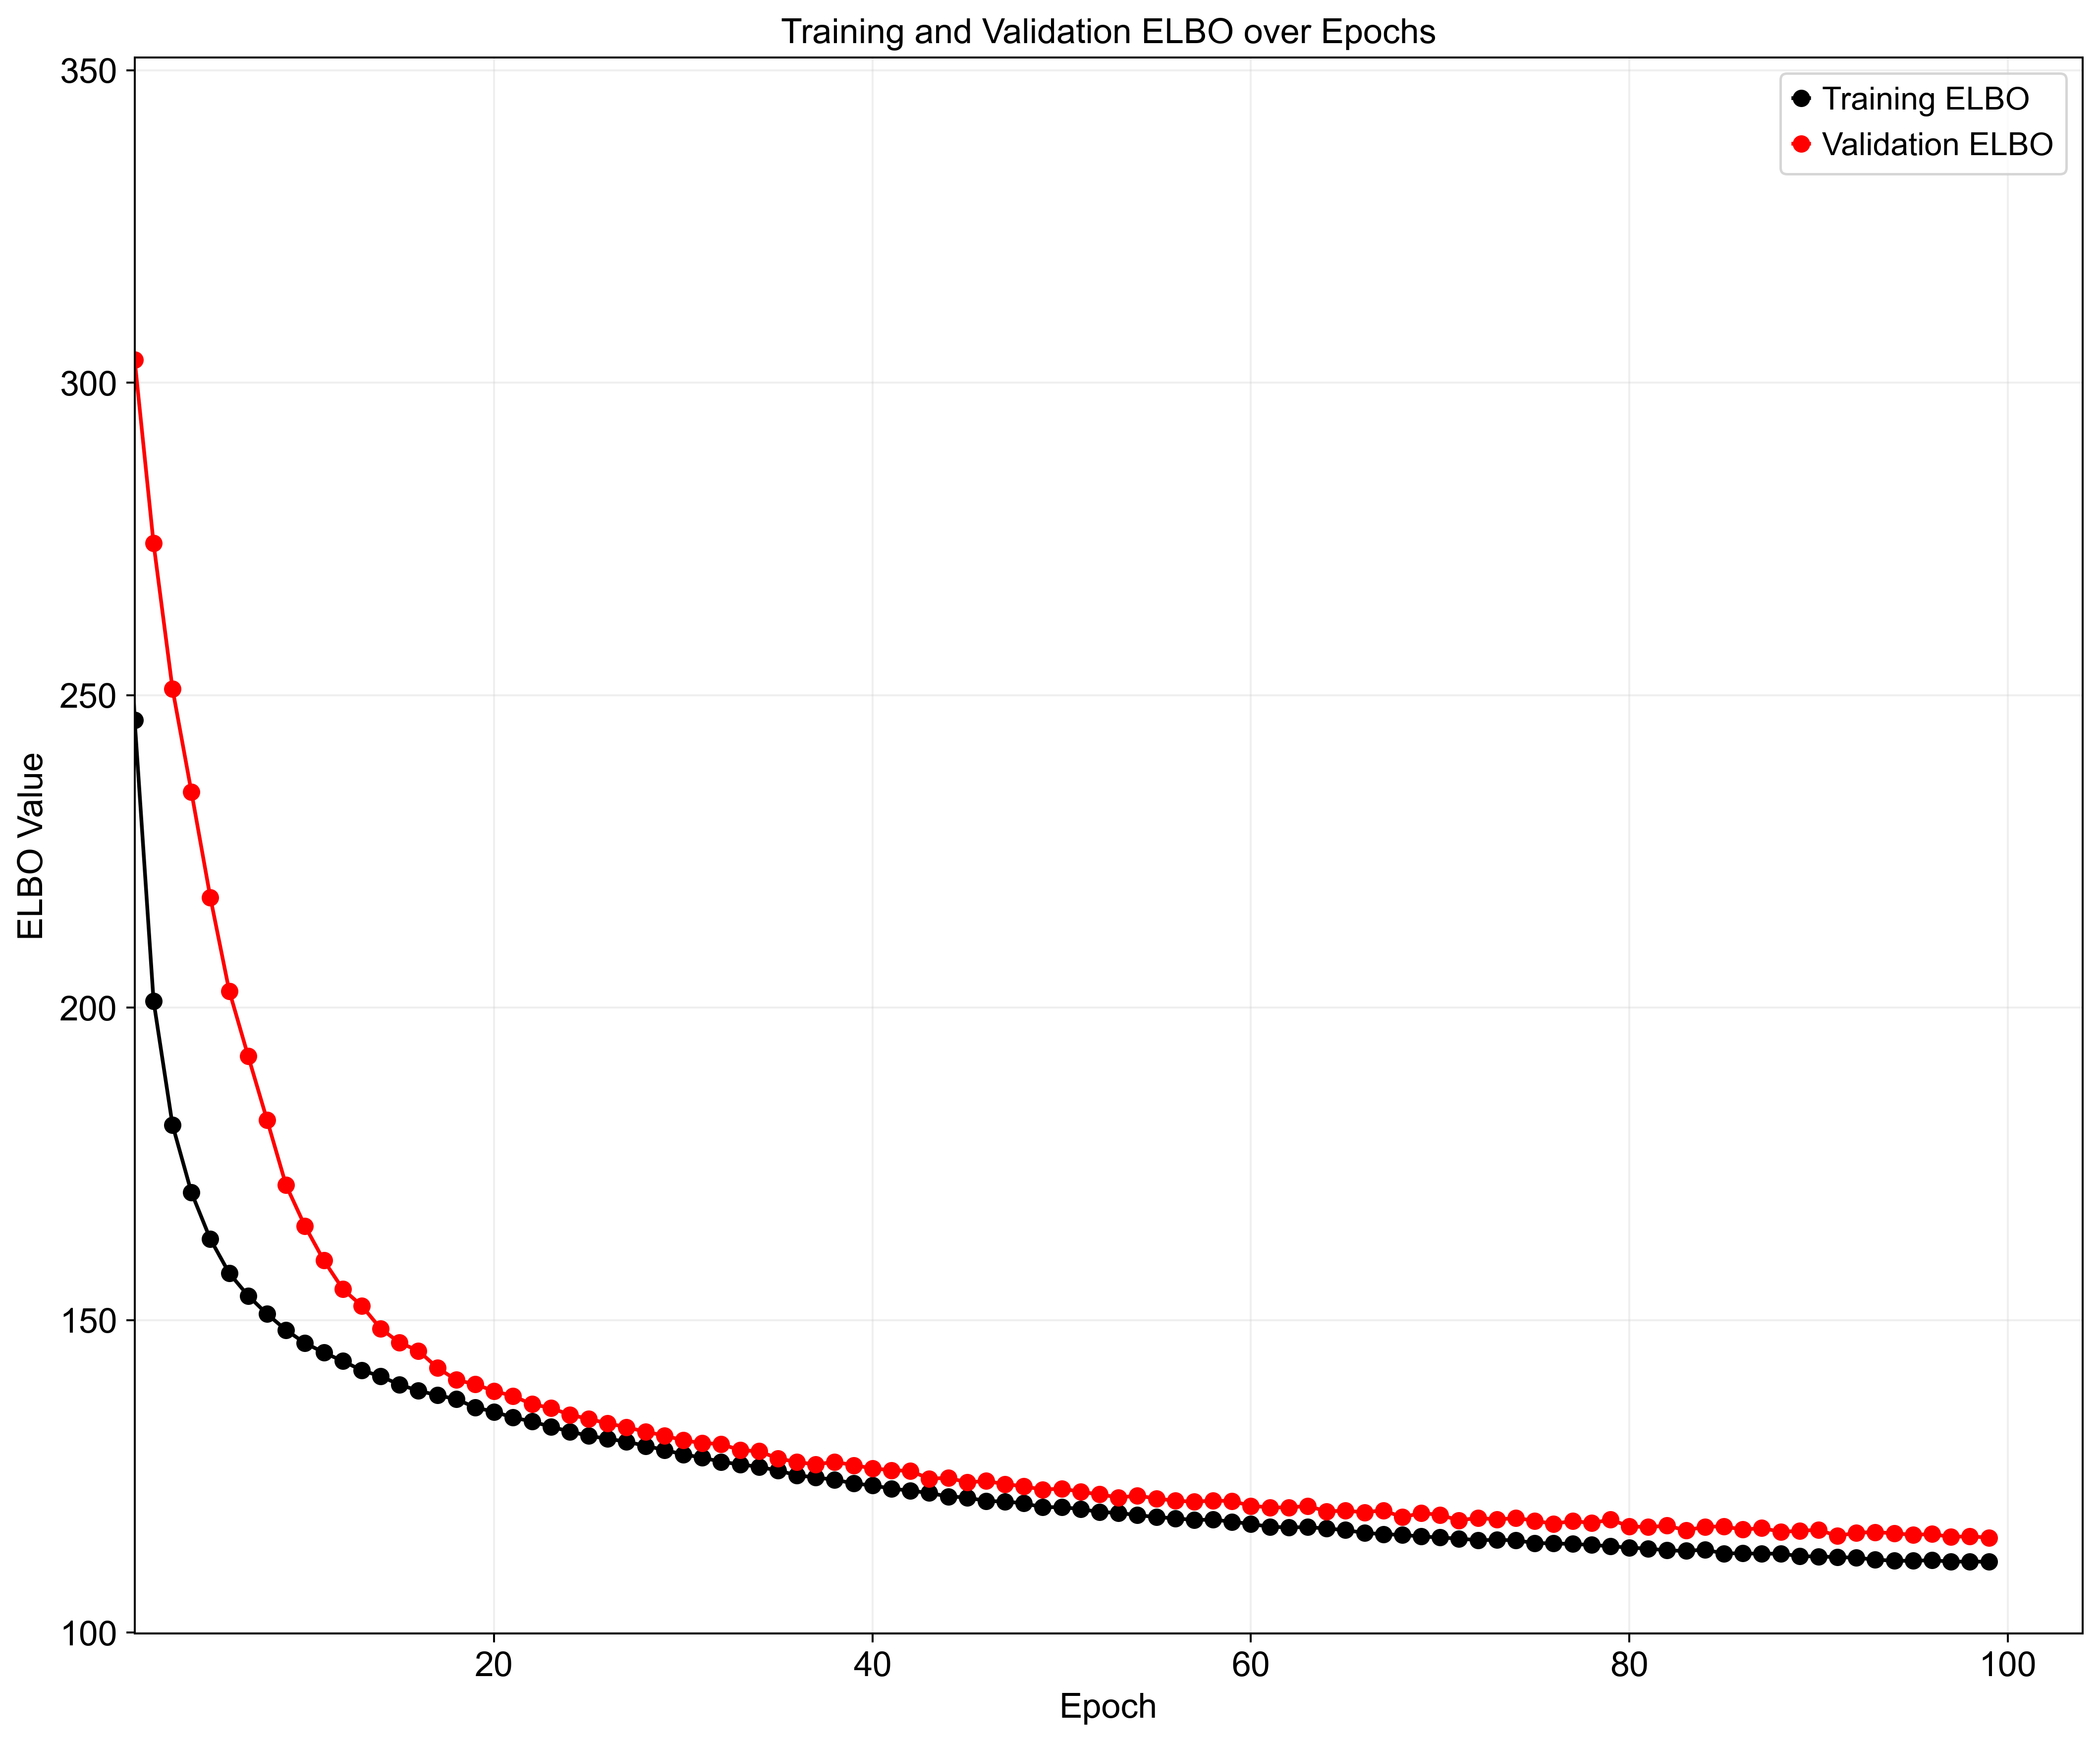

<Figure size 720x720 with 0 Axes>

In [21]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

plt.savefig(f'3_cell_states_annotation/figures/scvi_EEC_{timestamp}.png', dpi=300, bbox_inches='tight')

+ Visualize dataset

In [20]:
sc.pp.neighbors(adata_EEC, use_rep = "X_scVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata_EEC, min_dist = 0.3, spread = 4, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_EEC,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 15)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_EEC,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_continues_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

### `Leiden` clustering

In [21]:
sc.tl.leiden(adata_EEC, resolution = 0.2, random_state = 1786)

running Leiden clustering
    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


## Manual Annotation

In [22]:
adata_log = adata[adata.obs['cellstates_scANVI'] == 'EEC']
adata_log.obs['leiden'] = adata_EEC.obs['leiden'].copy()
adata_log.obsm['X_umap'] = adata_EEC.obsm['X_umap'].copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'REG4', 'APOA2', 'GCG', 'CRYBA2', 'GHRL', 'CCK', 'SST', 'GC', 'ALB', 'ATG10', 'MLN', 'ENSG00000287089', 'RPL30-AS1', 'LCN15', 'VIM-AS1', 'INS', 'BEST1', 'TALAM1', 'APOA4', 'APOA1', 'NTS', 'ENSG00000273149', 'GAST', 'PYY', 'GIP', 'TTR', 'ENSG00000267598', 'YIF1B', 'FTL', 'TFF3', 'TFF1', 'PCSK1N', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO2', 'MT-ND3', 'ENSG00000231067']
    finished (0:00:00)


In [23]:
adata_log.obs['cell_states'] = 'EECs'
adata_log.obs['cell_states'] = adata_log.obs['cell_states'].astype('category')
adata_log.obs['cell_states'] = adata_log.obs['cell_states'].cat.add_categories(['M/X cells (MLN/GHRL+)', 'D cells (SST+)', 'L cells (PYY+)', 'K cells (GIP+)',
                                                                                'N cells (NTS+)', 'CLDN10+ cells',
                                                                                'TA', 'EC cells (TAC1+)', 'I cells (CCK+)'])

* TA cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'MKI67', 'TOP2A', 'PCNA', 'CCNB1', 'CDC20', 'BIRC5', 'UBE2C'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_TA_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [24]:
adata_log.obs.loc[adata_log.obs['leiden'] == '1', 'cell_states'] = 'TA'

* M/X cells (MLN/GHRL+)

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'MLN', 'GHRL'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_M_X_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [25]:
adata_log.obs.loc[adata_log.obs['leiden'] == '5', 'cell_states'] = 'M/X cells (MLN/GHRL+)'
cluster_mask = adata_log.obs['leiden'] == '1'

gene_mask = (
    (adata_log[:, ['MLN', 'GHRL']].X.toarray() > 8)
    .any(axis=1)
)

adata_log.obs.loc[cluster_mask & gene_mask, 'cell_states'] = 'M/X cells (MLN/GHRL+)'

* D cells (SST+)

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'SST'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_D_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [26]:
cluster_4_mask = adata_log.obs['leiden'] == '4'
other_clusters_mask = adata_log.obs['leiden'].isin(['1', '3'])

sst_mask = adata_log[:, 'SST'].X.toarray().flatten() > 5

adata_log.obs.loc[cluster_4_mask | (other_clusters_mask & sst_mask), 'cell_states'] = 'D cells (SST+)'

* Enterochromaffin cells and CLDN10+ cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'TPH1', 'NPW', 'TAC1', 'CLDN10'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_Enterochromaffin_and_CLDN10_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [27]:
cluster_mask = adata_log.obs['leiden'] == '0'

cldn1_mask = adata_log[:, 'CLDN1'].X.toarray().flatten() > 3
adata_log.obs.loc[cluster_mask & cldn1_mask, 'cell_states'] = 'CLDN10+ cells'

ec_mask = (
    (adata_log[:, ['TPH1', 'TAC1']].X.toarray() > 3) 
    .any(axis=1)
)
adata_log.obs.loc[cluster_mask & ec_mask, 'cell_states'] = 'EC cells (TAC1+)'

+ Cluster 2 (mix of many cell states)

In [28]:
i_cells_mask = adata_log.obs['leiden'].isin(['6', '2'])
adata_log.obs.loc[i_cells_mask, 'cell_states'] = 'I cells (CCK+)'

cluster_2_mask = adata_log.obs['leiden'] == '2'
cluster_3_mask = adata_log.obs['leiden'] == '3'

# Identify K cells (GIP+)
gip_mask = adata_log[:, 'GIP'].X.toarray().flatten() > 8
adata_log.obs.loc[cluster_2_mask & gip_mask, 'cell_states'] = 'K cells (GIP+)'

# Identify I cells (CCK+) from cluster 3
cck_mask = adata_log[:, 'CCK'].X.toarray().flatten() > 8
adata_log.obs.loc[cluster_3_mask & cck_mask, 'cell_states'] = 'I cells (CCK+)'

# Identify L cells (PYY+) from cluster 2 with both GCG and PYY expression
l_cells_mask = (
    (adata_log[:, ['GCG', 'PYY']].X.toarray() > 5)
    .all(axis=1) 
)
adata_log.obs.loc[cluster_2_mask & l_cells_mask, 'cell_states'] = 'L cells (PYY+)'

# Identify N cells (NTS+)
nts_mask = adata_log[:, 'NTS'].X.toarray().flatten() > 8
adata_log.obs.loc[cluster_2_mask & nts_mask, 'cell_states'] = 'N cells (NTS+)'

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'GCG', 'PYY', 'NTS', 'GIP', 'CCK'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_I_K_L_N_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'cell_states'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/EEC_manual_annotation_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Transfer annotation to main object

In [29]:
adata.obs['cell_states'] = adata.obs['cellstates_scANVI'].copy()

In [30]:
all_categories = pd.Categorical(
    pd.concat([adata.obs['cell_states'], adata_log.obs['cell_states']]).unique()
)

adata.obs['cell_states'] = pd.Categorical(
    adata.obs['cell_states'],
    categories=all_categories
)

adata_log.obs['cell_states'] = pd.Categorical(
    adata_log.obs['cell_states'],
    categories=all_categories
)

In [31]:
shared_indices = adata_log.obs.index
adata.obs.loc[shared_indices, 'cell_states'] = adata_log.obs['cell_states']

In [32]:
adata.obs['cell_states'].value_counts()

cell_states
Enterocyte               28766
Proximal progenitor      26304
TA                       15143
Stem cells               13495
Colonocyte               11417
BEST4+ epithelial         6008
Goblet cell               5621
EECs                      1275
D cells (SST+)             418
I cells (CCK+)             383
M/X cells (MLN/GHRL+)      311
CLDN10+ cells              261
Distal progenitor          249
Tuft                       215
EC cells (TAC1+)           179
N cells (NTS+)              19
K cells (GIP+)              14
L cells (PYY+)              14
Paneth                      13
EEC                          0
Name: count, dtype: int64

In [33]:
del adata_EEC, adata_log

## Secretory cells: Goblet, Tuft and Paneth

In [34]:
adata_secretory = adata[adata.obs['cellstates_scANVI'].isin(['Goblet cell', 'Tuft', 'Paneth'])]
adata_secretory

View of AnnData object with n_obs × n_vars = 5849 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_

### Extract highly variable genes

In [35]:
adata_secretory.layers['counts'] = adata_secretory.X.copy()

In [36]:
sc.pp.highly_variable_genes(
    adata_secretory,
    flavor = "seurat_v3",
    n_top_genes = 1000,
    layer = "counts",
    batch_key = "library_preparation_protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


## Run scVI

In [37]:
scvi.model.SCVI.setup_anndata(adata_secretory, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Protocol REF'],
                              layer = 'counts')

In [38]:
scvi_model = scvi.model.SCVI(adata_secretory,
                            n_latent = 50, 
                            n_hidden = 128,
                            n_layers = 2, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [39]:
scvi_model.train(100, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:37<00:00,  2.50it/s, v_num=1, train_loss_step=169, train_loss_epoch=250]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:37<00:00,  2.70it/s, v_num=1, train_loss_step=169, train_loss_epoch=250]


In [40]:
adata_secretory.obsm["X_scVI"] = scvi_model.get_latent_representation(adata_secretory)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [53]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

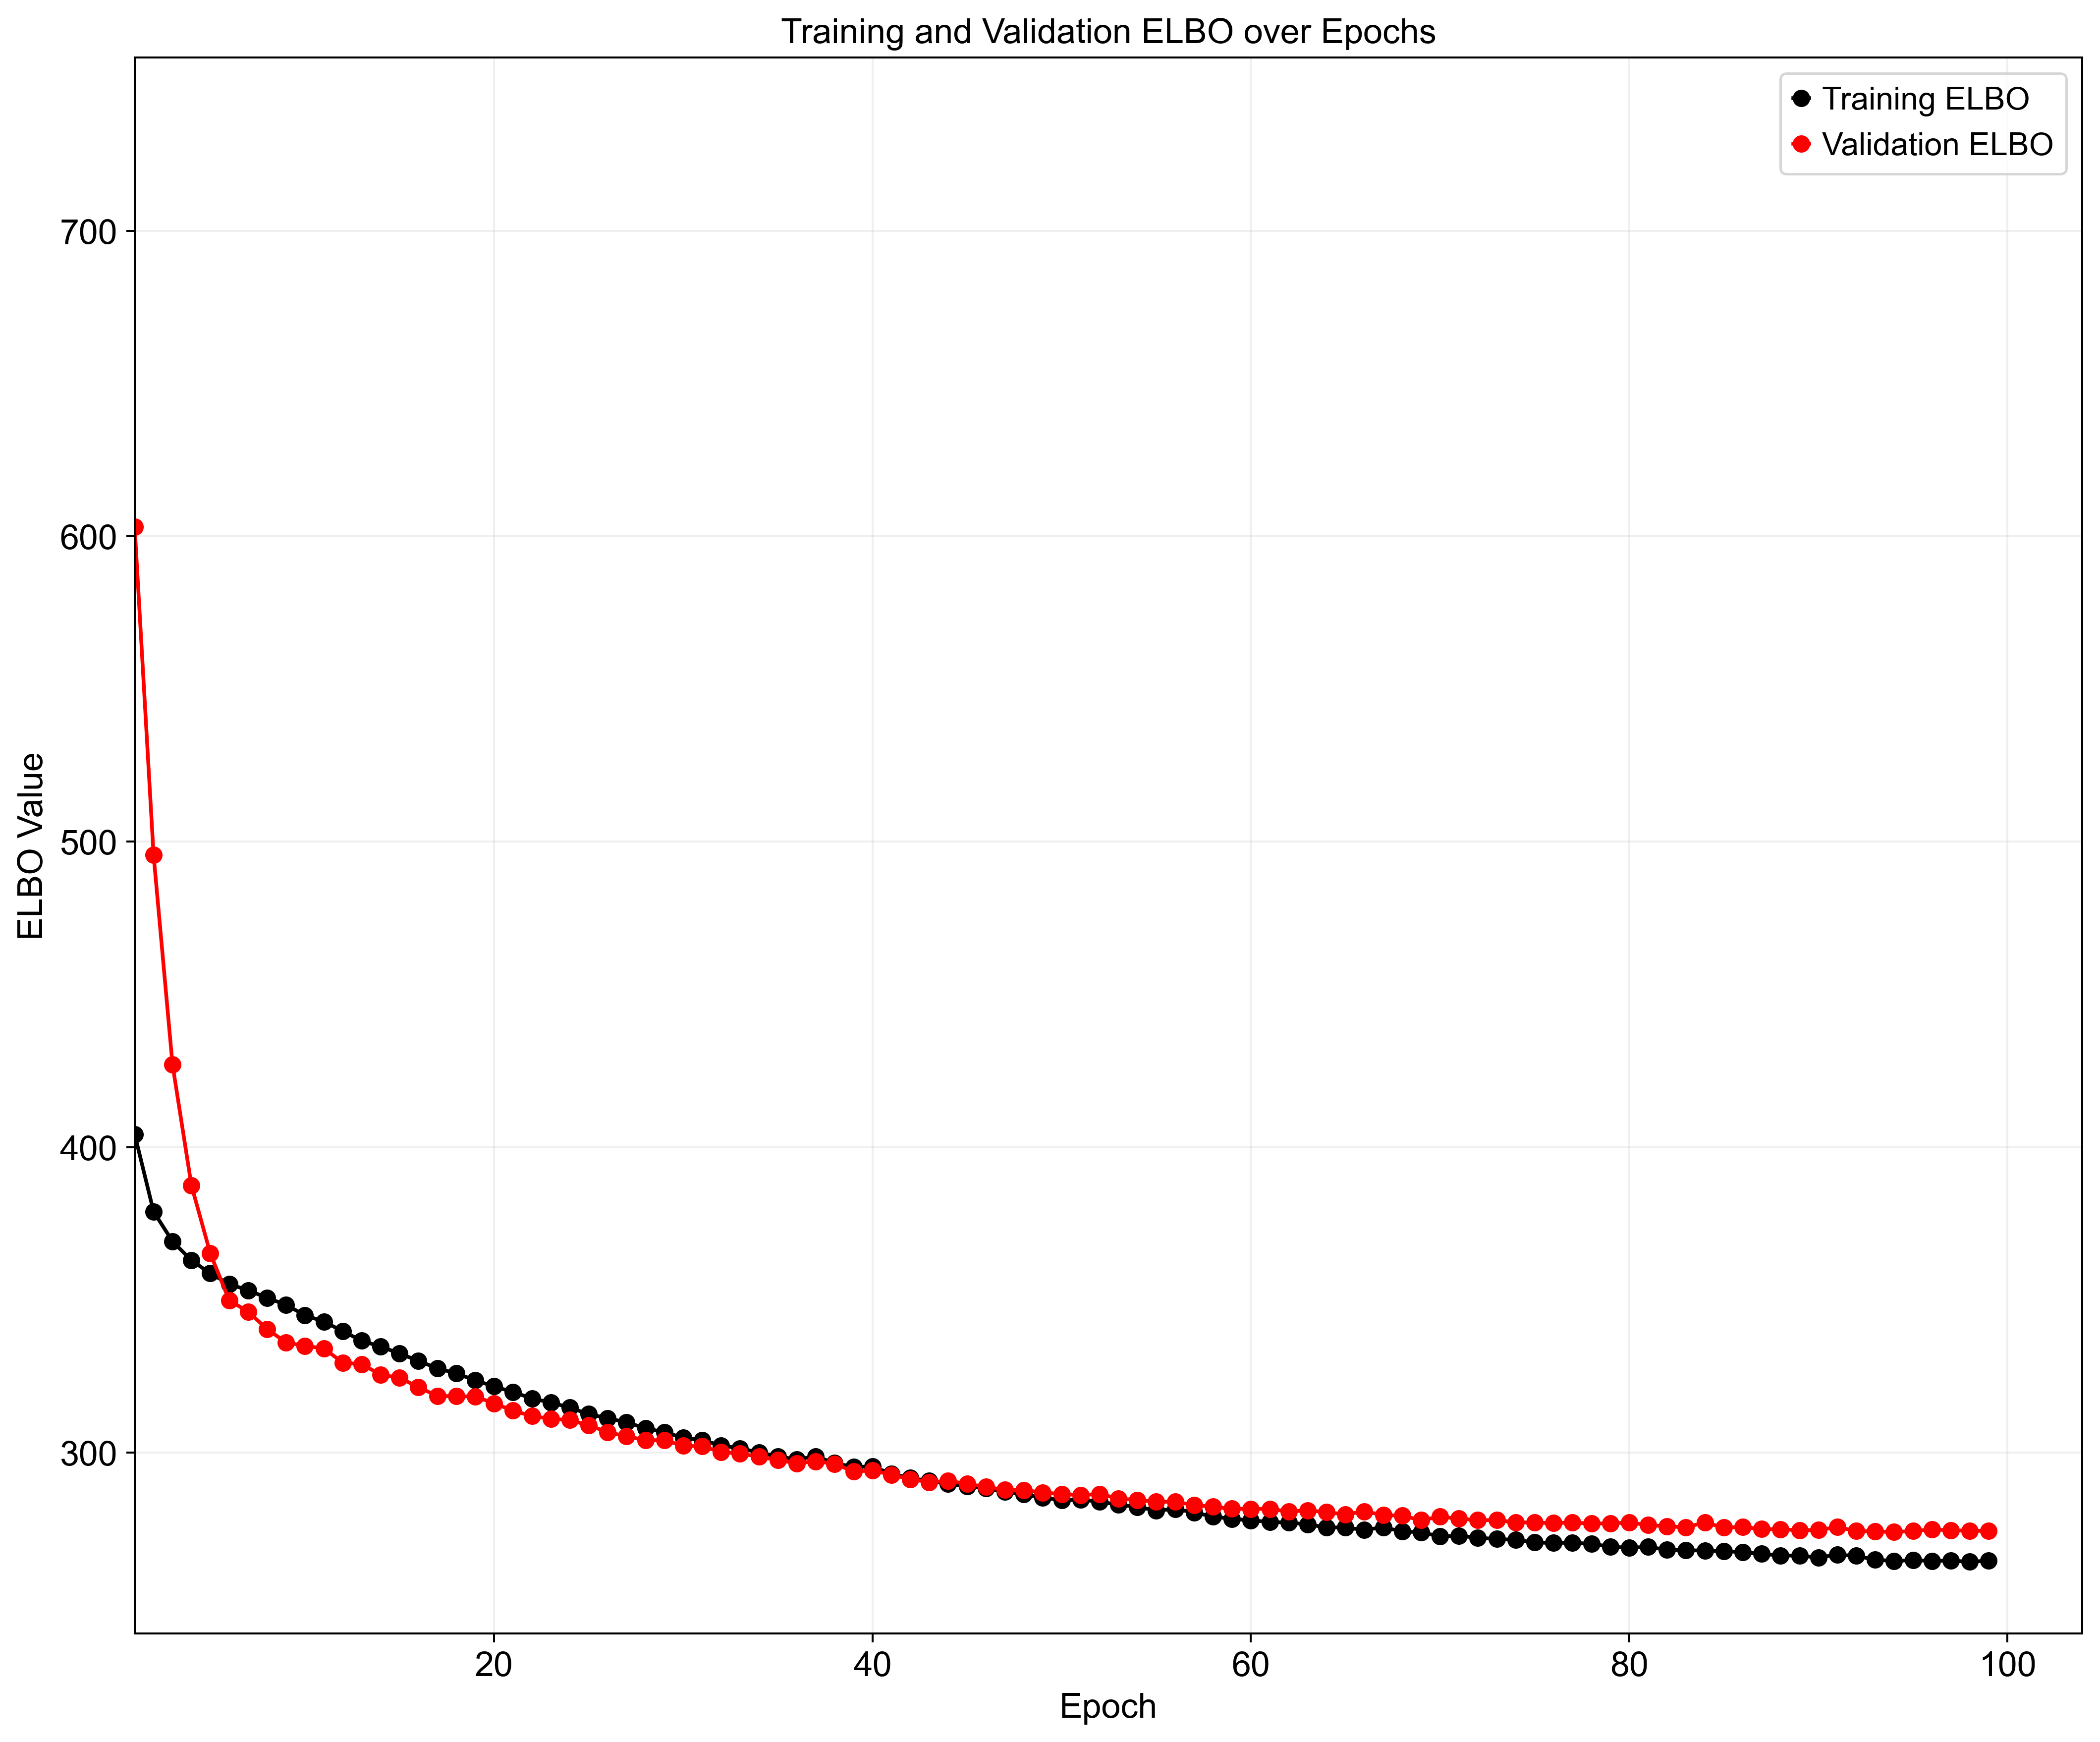

<Figure size 720x720 with 0 Axes>

In [54]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

plt.savefig(f'3_cell_states_annotation/figures/scvi_secretory_{timestamp}.png', dpi=300, bbox_inches='tight')

+ Visualize dataset

In [41]:
sc.pp.neighbors(adata_secretory, use_rep = "X_scVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata_secretory, min_dist = 0.3, spread = 4, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


In [56]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_secretory,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 15)
    plt.savefig(f"3_cell_states_annotation/figures/Secretory_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_secretory,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/Secretory_continues_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

### `Leiden` clustering

In [42]:
sc.tl.leiden(adata_secretory, resolution = 0.2, random_state = 1786)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


## Manual Annotation

In [43]:
adata_log = adata[adata.obs['cellstates_scANVI'].isin(['Goblet cell', 'Tuft', 'Paneth'])]
adata_log.obs['leiden'] = adata_secretory.obs['leiden'].copy()
adata_log.obsm['X_umap'] = adata_secretory.obsm['X_umap'].copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'CLCA1', 'S100A6', 'ITLN1', 'ITLN2', 'APOA2', 'REG3A', 'ENSG00000286848', 'JCHAIN', 'ATG10', 'AGR2', 'RPL30-AS1', 'RPS6', 'SPINK4', 'RPL12', 'LCN2', 'ADIRF-AS1', 'BEST1', 'FTH1', 'TALAM1', 'ENSG00000285513', 'APOA1', 'MRPS35-DT', 'LYZ', 'ENSG00000257764', 'ENSG00000273149', 'ZG16', 'MT1G', 'MT1H', 'YIF1B', 'FTL', 'TFF3', 'TFF2', 'TFF1', 'IGLC2', 'IGLC3', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-ND6', 'MUC2-1']
    finished (0:00:00)


In [44]:
adata_log.obs['cell_states'] = adata_log.obs['cell_states'].cat.add_categories(['immature Goblet cell', 'mature Goblet cell', 'Deep crypt secretory cells'])

* Mature Goblet cells

In [62]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'MUC2','SPDEF','TFF3','CLCA1','FCGBP','ZG16', 'WFDC2', 'BEST2'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/secretory_mature_goblet_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [45]:
adata_log.obs.loc[adata_log.obs['leiden'] == '1', 'cell_states'] = 'mature Goblet cell'

+ Immature Goblet

In [64]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'FOXA2', 'LGR5', 'MYC', 'UBE2C', 'MKI67'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/secretory_immature_goblet_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [46]:
adata_log.obs.loc[adata_log.obs['leiden'] == '2', 'cell_states'] = 'immature Goblet cell'

+ Paneth cells

In [66]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'DEFA5', 'REG3A','LYZ', 'PLA2G2A', 'REG4', 'SPINK4','TRPM5', 'NPR3', 'AGR3','MYO5B', 'gut_region'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/secretory_Paneth_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [47]:
adata_log.obs.loc[adata_log.obs['leiden'] == '3', 'cell_states'] = 'Paneth'

In [48]:
cluster_mask = adata_log.obs['leiden'] == '4'

locations_mask  = adata_log.obs['gut_region'] == 'large intestine'

adata_log.obs.loc[cluster_mask & locations_mask, 'cell_states'] = 'Deep crypt secretory cells'

In [69]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['leiden', 'cell_states'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/secretory_manual_annotation_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [49]:
all_categories = pd.Categorical(
    pd.concat([adata.obs['cell_states'], adata_log.obs['cell_states']]).unique()
)

adata.obs['cell_states'] = pd.Categorical(
    adata.obs['cell_states'],
    categories=all_categories
)

adata_log.obs['cell_states'] = pd.Categorical(
    adata_log.obs['cell_states'],
    categories=all_categories
)

In [50]:
shared_indices = adata_log.obs.index
adata.obs.loc[shared_indices, 'cell_states'] = adata_log.obs['cell_states']

In [51]:
adata.obs['cell_states'].value_counts()

cell_states
Enterocyte                    28766
Proximal progenitor           26304
TA                            15143
Stem cells                    13495
Colonocyte                    11417
BEST4+ epithelial              6008
Goblet cell                    2295
mature Goblet cell             1563
immature Goblet cell           1452
EECs                           1275
D cells (SST+)                  418
I cells (CCK+)                  383
Paneth                          329
M/X cells (MLN/GHRL+)           311
CLDN10+ cells                   261
Distal progenitor               249
Tuft                            200
EC cells (TAC1+)                179
N cells (NTS+)                   19
L cells (PYY+)                   14
K cells (GIP+)                   14
Deep crypt secretory cells       10
Name: count, dtype: int64

In [52]:
del adata_secretory, adata_log

## Differentiated: Enterocytes, colonocytes and BEST4+ epithelial

In [53]:
adata_differentiated = adata[adata.obs['cellstates_scANVI'].isin(['Enterocyte', 'Colonocyte', 'BEST4+ epithelial'])]
adata_differentiated

View of AnnData object with n_obs × n_vars = 46191 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation

### Extract highly variable genes

In [54]:
adata_differentiated.layers['counts'] = adata_differentiated.X.copy()

In [55]:
sc.pp.highly_variable_genes(
    adata_differentiated,
    flavor = "seurat_v3",
    n_top_genes = 1500,
    layer = "counts",
    batch_key = "library_preparation_protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


## Run scVI

In [56]:
scvi.model.SCVI.setup_anndata(adata_differentiated, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Protocol REF'],
                              layer = 'counts')

In [57]:
scvi_model = scvi.model.SCVI(adata_differentiated,
                            n_latent = 50, 
                            n_hidden = 128,
                            n_layers = 2, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [58]:
scvi_model.train(100, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:35<00:00,  4.05s/it, v_num=1, train_loss_step=373, train_loss_epoch=394]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:35<00:00,  3.96s/it, v_num=1, train_loss_step=373, train_loss_epoch=394]


In [59]:
adata_differentiated.obsm["X_scVI"] = scvi_model.get_latent_representation(adata_differentiated)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [60]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

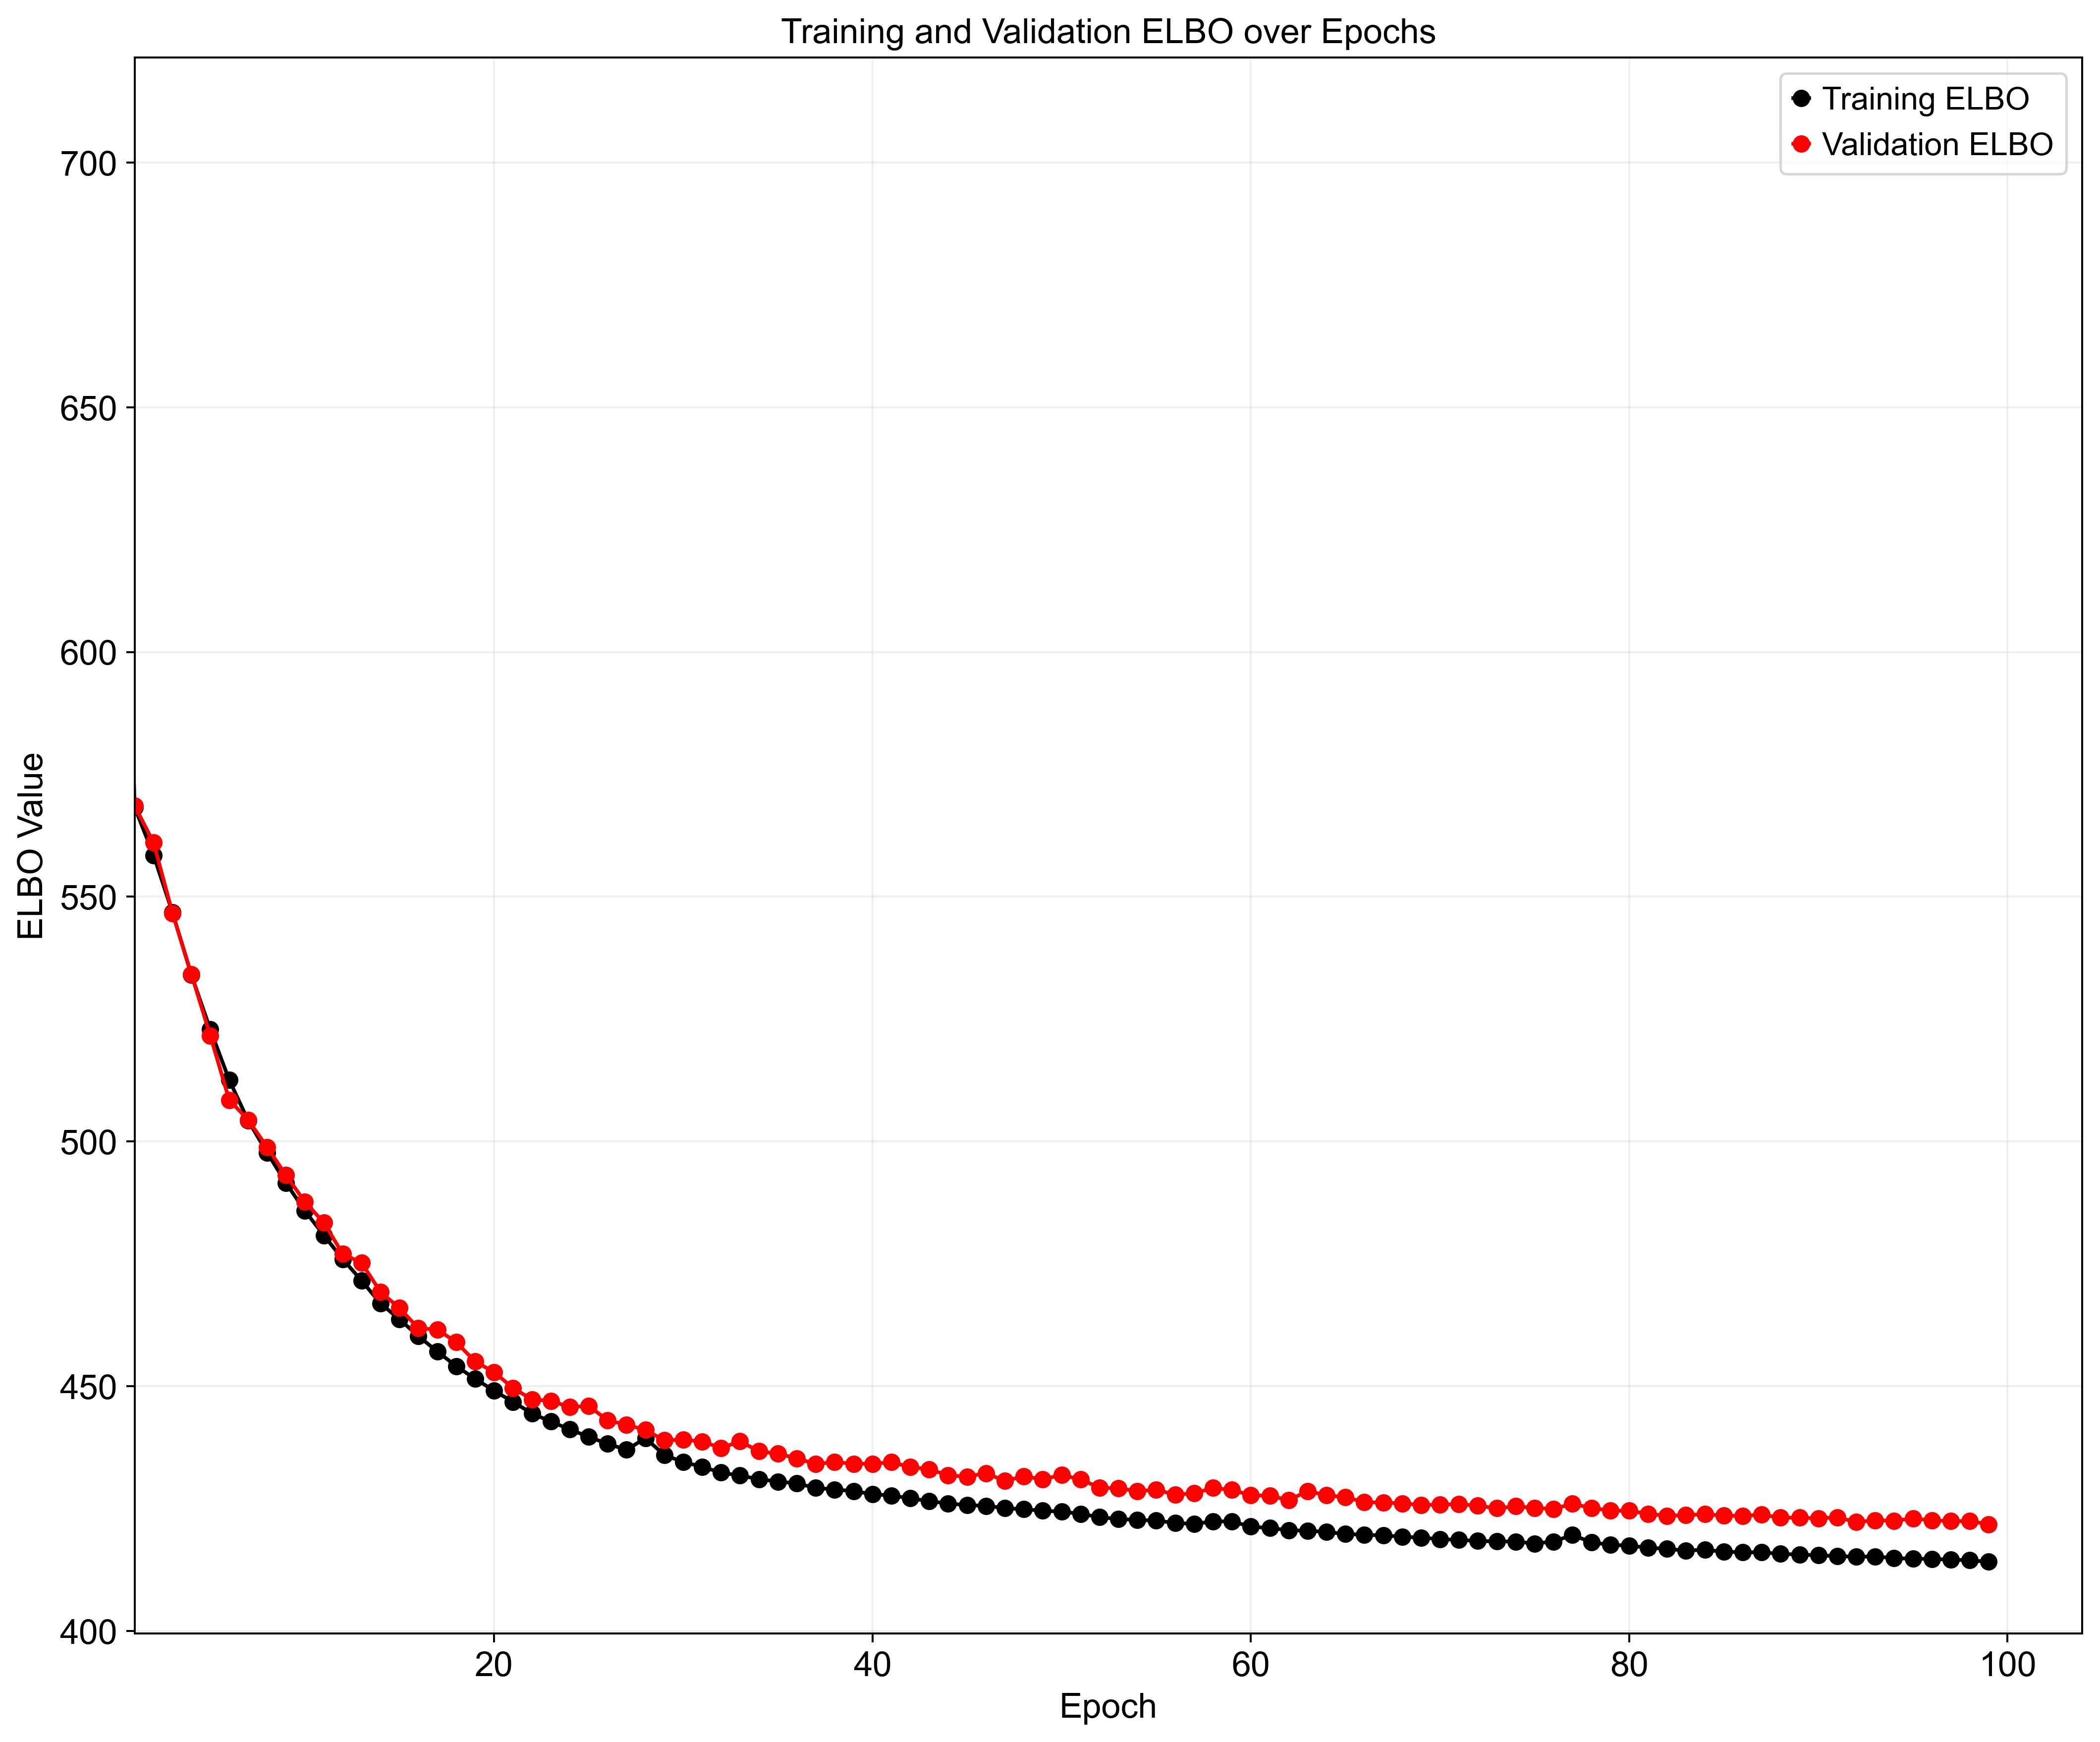

<Figure size 720x720 with 0 Axes>

In [61]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

plt.savefig(f'3_cell_states_annotation/figures/scvi_differentiated_absorptive_{timestamp}.png', dpi=300, bbox_inches='tight')

+ Visualize dataset

In [62]:
sc.pp.neighbors(adata_differentiated, use_rep = "X_scVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata_differentiated, min_dist = 0.3, spread = 4, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:25)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_differentiated,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 15)
    plt.savefig(f"3_cell_states_annotation/figures/differentiated_absorptive_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_differentiated,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/differentiated_absorptive_continues_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Manual Annotation

In [65]:
adata_log = adata[adata.obs['cellstates_scANVI'].isin(['Enterocyte', 'Colonocyte', 'BEST4+ epithelial'])]
adata_log.obsm['X_umap'] = adata_differentiated.obsm['X_umap'].copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GUCA2B', 'GUCA2A', 'ATP1A1-AS1', 'S100A6', 'APOA2', 'PIGR', 'REG1A', 'REG3A', 'FABP1', 'RBP2', 'SST', 'JCHAIN', 'ALB', 'AFP', 'RPL34', 'CCDC152', 'ATG10', 'SPINK1', 'FABP6', 'ENSG00000271581', 'CLPS', 'RPL30-AS1', 'LCN2', 'LCN15', 'VIM-AS1', 'ADIRF-AS1', 'SHLD2', 'BEST1', 'TALAM1', 'ENSG00000285513', 'APOA4', 'APOC3', 'APOA1', 'APOA1-AS', 'LYZ', 'ENSG00000257764', 'TPT1', 'ENSG00000273149', 'PHGR1', 'MT2A', 'MT1G', 'MT1H', 'TTR', 'ENSG00000267598', 'YIF1B', 'FTL', 'TFF3', 'TFF2', 'TFF1', 'IGLC2', 'IGLC3', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-ND3', 'MT-ND4', 'MT-ND6']
    finished (0:00:00)


* Microfold cells

In [66]:
sc.tl.score_genes(adata_log, ['GP2', 'SPIB', 'CCL20'], score_name='microfold_score')

computing score 'microfold_score'
    finished: added
    'microfold_score', score of gene set (adata.obs).
    150 total control genes are used. (0:00:00)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['GP2', 'SPIB', 'CCL20', 'gut_region', 'cell_states', 'microfold_score'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/Differentiated_absorptive_microfold_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [68]:
adata_log.obs['cell_states'] = adata_log.obs['cell_states'].cat.add_categories('Microfold cells')
adata_log.obs.loc[adata_log.obs['microfold_score'] > 4, 'cell_states'] = 'Microfold cells'

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['GP2', 'SPIB', 'CCL20', 'gut_region', 'cell_states'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/Differentiated_absorptive_enterocytes_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['CA2', 'AQP8', 'SLC26A3', 'FABP1', 'gut_region', 'cell_states'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/Differentiated_absorptive_colonocytes_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['BEST4', 'CA7', 'OTOP2', 'gut_region', 'cell_states'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"3_cell_states_annotation/figures/Differentiated_absorptive_best4_enterocytes_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata,color=['cell_states'], ncols=4, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/final_annotation_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Transfer annotation to full dataset

In [72]:
all_categories = pd.Categorical(
    pd.concat([adata.obs['cell_states'], adata_log.obs['cell_states']]).unique()
)

adata.obs['cell_states'] = pd.Categorical(
    adata.obs['cell_states'],
    categories=all_categories
)

adata_log.obs['cell_states'] = pd.Categorical(
    adata_log.obs['cell_states'],
    categories=all_categories
)

In [73]:
shared_indices = adata_log.obs.index
adata.obs.loc[shared_indices, 'cell_states'] = adata_log.obs['cell_states']

In [74]:
adata.obs['cell_states'].value_counts()

cell_states
Enterocyte                    28751
Proximal progenitor           26304
TA                            15143
Stem cells                    13495
Colonocyte                    11415
BEST4+ epithelial              5749
Goblet cell                    2295
mature Goblet cell             1563
immature Goblet cell           1452
EECs                           1275
D cells (SST+)                  418
I cells (CCK+)                  383
Paneth                          329
M/X cells (MLN/GHRL+)           311
Microfold cells                 276
CLDN10+ cells                   261
Distal progenitor               249
Tuft                            200
EC cells (TAC1+)                179
N cells (NTS+)                   19
L cells (PYY+)                   14
K cells (GIP+)                   14
Deep crypt secretory cells       10
Name: count, dtype: int64

In [75]:
del adata_differentiated, adata_log

## Save prepared dataset

In [76]:
current_history = adata.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Manually annotated cell states',
})
current_history.append(new_entry)

adata.uns['processing_history'] = current_history

In [77]:
adata.obs.rename(columns={'cell_id': 'cell_index'}, inplace=True)

In [78]:
adata

AnnData object with n_obs × n_vars = 110105 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [79]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_epithelial_annotated'

adata.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")